In [5]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [6]:
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [7]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}  
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [8]:
import random
random.seed(42)
random.shuffle(words)

In [38]:

block_size = 8
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X, device=device)
    Y = torch.tensor(Y, device=device)
    return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xtes, Ytes = build_dataset(words[n2:])

In [39]:
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g, device=device) / fan_in**0.5
    self.bias = torch.zeros(fan_out, device=device) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.gamma = torch.ones(dim, device=device)
        self.beta = torch.zeros(dim, device=device)
        self.running_mean = torch.zeros(dim, device=device)
        self.running_var = torch.ones(dim, device=device)
        self.eps = eps
        self.momentum = momentum
        self.training = True

    def __call__(self, x):
        if self.training:
            x_mean = x.mean(0, keepdim=True)
            x_var = x.var(0, keepdim=True, unbiased=False)
        else:
            x_mean = self.running_mean
            x_var = self.running_var
        xhat = (x - x_mean) / torch.sqrt(x_var + self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * x_mean
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * x_var
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

class Embedding:
    def __init__(self, vocab_size, n_embd):
        self.weight = torch.randn((vocab_size, n_embd), device=device) / n_embd**0.5

    def __call__(self, x):
        self.out = self.weight[x]
        return self.out
    
    def parameters(self):
        return [self.weight]

class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out
    
    def parameters(self):
        return []

class Sequential:
    def __init__(self, layers):
        self.layers = layers
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    

In [40]:
torch.manual_seed(42)

In [31]:
n_embd = 10        # embedding dimension
n_hidden = 200     # number of hidden units

# C = torch.randn((vocab_size, n_embd), device=device)

model = Sequential([
    Embedding(vocab_size, n_embd), 
    Flatten(),
    Linear(n_embd*block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size)
])
with torch.no_grad():
    model.layers[-1].weight *= 0.1


parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

12097


In [33]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f"{i:7d}/{max_steps}: {loss.item():.4f}")
    lossi.append(loss.log10().item())
    break

      0/200000: 3.2957


In [ ]:
plt.plot(lossi)

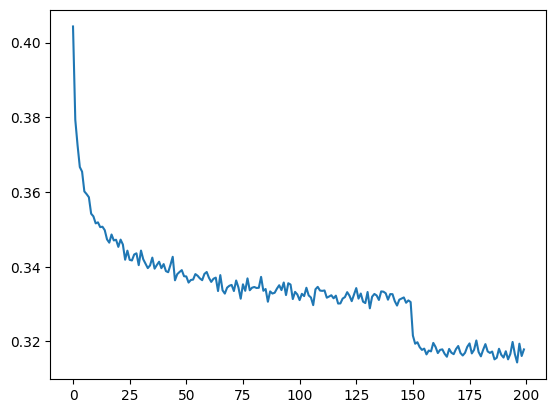

In [23]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [36]:
for layer in model.layers:
    layer.training = False

In [34]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xval, Yval),
        'test': (Xtes, Ytes),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(f"{split} loss: {loss.item():.4f}")

split_loss('train')
split_loss('val')

train loss: 3.2723
val loss: 3.2716


In [37]:
# sample from the model
g = torch.Generator(device).manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context], device=device))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

qbkdtsyhyznmvdrfrylmjjvhorbrsuucbzfidzjofurhhhqwivcqygtppdgnwwzmqcsfnmpwqtbqelcohixabstttgtjtqnggqcdkkpvqzhpaan.
c.
ilanx.
uoigf.
qqvrugvhwfbkzokqsqzqksvckgpbg.
nncxcmzpm.
gtebrpkxwzbeulijgcffea.
h.
rdmmclgcbxuvaulayfgvp.
nofstnjnwsrfpaqflvhmvebsoegldyojbx.
nevqhupnrhgwvjgwrkxivynbpcrpjfikmbymmf.
idljrdfmqb.
znyzfmfufjkevhkbzahvpyuxbkbejsjfawjcijwhzgbzsupfqxckinubkswtmehprqjb.
umqsbjzksnnmvszyvdcdo.
yjwwvmxcbzjdekfefeusfjmkigieprfdxxsrtolycmjzyuemffdsfuuecbdkaksruefgggg.
riuaiojrmwdektcihcgjs.
hywuklnflc.
lglzcshzjsqxrztmfgemajx.
bjykaoknsovbrvxzfrfuxvjshmsgrxjlawltshydbgocjbbrffzemkwwqk.
twrsbkikvdvjiwwr.
